# Segmentation ensemble test-only notebook (corrected)

Ez a notebook csak tesztkiértékelést végez a validáción kiválasztott, fix ensemble súlyokkal.

In [ ]:

# 0) Colab / package setup


try:
    import segmentation_models_pytorch as smp
except Exception:
    !pip -q install segmentation-models-pytorch

try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except Exception:
    !pip -q install albumentations

In [ ]:
# 2) Google Drive mount

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


# 1) Imports

import os
import gc
import json
import time
import math
import random
from dataclasses import dataclass, asdict
from typing import Dict, Tuple, List, Optional

import numpy as np
import pandas as pd
from PIL import Image

import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from tqdm.auto import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

from sklearn.model_selection import train_test_split

try:
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("SMP:", smp.__version__)

Torch: 2.10.0+cu128
CUDA available: True
SMP: 0.5.0


In [ ]:
# 3) Config

@dataclass
class CFG:
    # --- data ---
    root_path: str = "/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test"
    image_dir: str = "/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/images"
    mask_dir: str = "/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/masks"

    # --- outputs ---
    output_dir: str = "/content/drive/MyDrive/Brain MRI/ensemble_test_results"

    # --- fixed ensemble weights selected on validation ---
    best_weights_json: str = "/content/drive/MyDrive/Brain MRI/segmentation_ensemble_results/best_weights.json"
    require_best_weights_json: bool = True

    # --- checkpoints ---
    unet_ckpt: str = "/content/drive/MyDrive/Brain MRI/FNO_seg/Unet_FNO_2/models/unetfno_run1_best_model.pt"
    attunet_ckpt: str = "/content/drive/MyDrive/Brain MRI/FNO_seg/AttentionUnet_FNO/models/run1_att_fno_best_model.pt"
    deeplab_ckpt: str = "/content/drive/MyDrive/Brain MRI/FNO_seg/Deeplabv3plus/best_model.pt"

    # --- reproducibility ---
    seed: int = 42

    # --- loader ---
    batch_size: int = 1
    num_workers: int = 0
    pin_memory: bool = True

    # --- model input sizes used during training ---
    unet_size: int = 256
    attunet_size: int = 256
    deeplab_size: int = 320

    # --- common evaluation size ---
    eval_size: int = 320

    # --- model params ---
    in_channels: int = 1
    num_classes: int = 2
    fno_modes: int = 4

    # --- DeepLabV3+ params needed for checkpoint-compatible reconstruction ---
    deeplab_encoder_name: str = "resnet34"
    # In inference we load the encoder from checkpoint, so None is safest.
    deeplab_encoder_weights: Optional[str] = None

    # --- inference ---
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    use_tta: bool = False
    threshold: float = 0.5  # not used for argmax multiclass inference

cfg = CFG()
os.makedirs(cfg.output_dir, exist_ok=True)
print(cfg)

for p in [cfg.image_dir, cfg.mask_dir, cfg.unet_ckpt, cfg.attunet_ckpt, cfg.deeplab_ckpt, cfg.best_weights_json]:
    print(f"EXISTS? {p} -> {os.path.exists(p)}")

CFG(root_path='/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test', image_dir='/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/images', mask_dir='/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/masks', output_dir='/content/drive/MyDrive/Brain MRI/ensemble_test_results', best_weights_json='/content/drive/MyDrive/Brain MRI/segmentation_ensemble_results/best_weights.json', require_best_weights_json=True, unet_ckpt='/content/drive/MyDrive/Brain MRI/FNO_seg/Unet_FNO_2/models/unetfno_run1_best_model.pt', attunet_ckpt='/content/drive/MyDrive/Brain MRI/FNO_seg/AttentionUnet_FNO/models/run1_att_fno_best_model.pt', deeplab_ckpt='/content/drive/MyDrive/Brain MRI/FNO_seg/Deeplabv3plus/best_model.pt', seed=42, batch_size=1, num_workers=0, pin_memory=True, unet_size=256, attunet_size=256, deeplab_size=320, eval_size=320, in_channels=1, num_classes=2, fno_modes=4, deeplab_encoder_name='resnet34', deeplab_encoder_weights=None, device='cuda', use_tta=F

In [ ]:

# 4) Reproducibility

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)

In [ ]:
# 5) Dataset utilities

VALID_EXTS = ('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp')

def list_image_files(folder: str):
    files = sorted([f for f in os.listdir(folder) if f.lower().endswith(VALID_EXTS)])
    if len(files) == 0:
        raise ValueError(f'Nincsenek képek itt: {folder}')
    return files

def infer_mask_filename(image_filename: str, available_masks: set):
    if image_filename in available_masks:
        return image_filename
    stem, _ = os.path.splitext(image_filename)
    for ext in ['.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp']:
        cand = stem + ext
        if cand in available_masks:
            return cand
    raise FileNotFoundError(f'Nem találok maszkot ehhez a képhez: {image_filename}')

class RawSegmentationDataset(Dataset):
    """
    Nyers, grayscale képet és maszkot ad vissza numpy formában.
    A modellekhez szükséges resize/normalization később, modellenként történik.
    """
    def __init__(self, image_dir: str, mask_dir: str, filenames: List[str]):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = filenames
        self.available_masks = set(list_image_files(mask_dir))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        image_name = self.filenames[idx]
        mask_name = infer_mask_filename(image_name, self.available_masks)

        image_path = os.path.join(self.image_dir, image_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = Image.open(image_path).convert('L')
        mask = Image.open(mask_path).convert('L')

        image_np = np.array(image, dtype=np.uint8)
        mask_np = np.array(mask, dtype=np.uint8)
        mask_np = (mask_np > 127).astype(np.uint8)

        return {
            'image': image_np,
            'mask': mask_np,
            'id': os.path.splitext(image_name)[0],
            'image_name': image_name,
            'mask_name': mask_name,
        }

def collate_raw(batch):
    return batch

In [ ]:

# Test dataset + loader

all_test_images = list_image_files(cfg.image_dir)
test_dataset = RawSegmentationDataset(cfg.image_dir, cfg.mask_dir, all_test_images)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory,
    collate_fn=collate_raw
)

print(f"Test minták száma: {len(test_dataset)}")
sample = test_dataset[0]
print("Első eset:", sample["id"], sample["image"].shape, sample["mask"].shape)


Test minták száma: 860
Első eset: brisc2025_test_00001_gl_ax_t1 (512, 512) (512, 512)


In [ ]:
# 7) Model-specific preprocess

def preprocess_grayscale_numpy(image_np: np.ndarray, target_size: int, mean: float, std: float):
    image_resized = cv2.resize(image_np, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
    image_resized = image_resized.astype(np.float32) / 255.0
    image_resized = (image_resized - mean) / std
    image_resized = np.expand_dims(image_resized, axis=0)  # (1,H,W)
    return torch.from_numpy(image_resized).float()

def preprocess_mask_numpy(mask_np: np.ndarray, target_size: int):
    mask_resized = cv2.resize(mask_np.astype(np.uint8), (target_size, target_size), interpolation=cv2.INTER_NEAREST)
    return torch.from_numpy(mask_resized.astype(np.int64))

# U-Net+FNO training preprocessing:
# image /255 only
def preprocess_unet(image_np):
    return preprocess_grayscale_numpy(image_np, cfg.unet_size, mean=0.0, std=1.0)

def preprocess_attunet(image_np):
    return preprocess_grayscale_numpy(image_np, cfg.attunet_size, mean=0.0, std=1.0)

# DeepLab training preprocessing:
# A.Normalize(mean=(0.5,), std=(0.5,))
def preprocess_deeplab(image_np):
    return preprocess_grayscale_numpy(image_np, cfg.deeplab_size, mean=0.5, std=0.5)

def preprocess_mask_eval(mask_np):
    return preprocess_mask_numpy(mask_np, cfg.eval_size)

In [ ]:
# 8) Metrics

def dice_binary_from_masks(pred_mask: np.ndarray, true_mask: np.ndarray, eps: float = 1e-7):
    pred_mask = pred_mask.astype(np.uint8)
    true_mask = true_mask.astype(np.uint8)
    intersection = (pred_mask * true_mask).sum()
    return (2.0 * intersection + eps) / (pred_mask.sum() + true_mask.sum() + eps)

def iou_binary_from_masks(pred_mask: np.ndarray, true_mask: np.ndarray, eps: float = 1e-7):
    pred_mask = pred_mask.astype(np.uint8)
    true_mask = true_mask.astype(np.uint8)
    intersection = (pred_mask * true_mask).sum()
    union = pred_mask.sum() + true_mask.sum() - intersection
    return (intersection + eps) / (union + eps)

def compute_case_metrics(pred_mask: np.ndarray, true_mask: np.ndarray):
    dice = dice_binary_from_masks(pred_mask, true_mask)
    iou = iou_binary_from_masks(pred_mask, true_mask)
    return {'dice': float(dice), 'iou': float(iou)}

def bootstrap_ci(values, n_boot=2000, alpha=0.05, seed=42):
    values = np.asarray(values, dtype=np.float64)
    rng = np.random.default_rng(seed)
    means = []
    n = len(values)
    for _ in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        means.append(sample.mean())
    lo = np.percentile(means, 100 * (alpha / 2))
    hi = np.percentile(means, 100 * (1 - alpha / 2))
    return float(lo), float(hi)

In [ ]:


# 9) Checkpoint-compatible model definitions
#    (exactly matching the FNO training notebooks)

@torch.jit.script
def compl_mul2d(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return torch.einsum("bixy, ioxy->boxy", a, b)

class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat)
        )
        self.weights2 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat)
        )

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfftn(x, dim=[2, 3])

        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-2),
            x.size(-1) // 2 + 1,
            device=x.device,
            dtype=torch.cfloat
        )

        out_ft[:, :, :self.modes1, :self.modes2] = compl_mul2d(
            x_ft[:, :, :self.modes1, :self.modes2], self.weights1
        )
        out_ft[:, :, -self.modes1:, :self.modes2] = compl_mul2d(
            x_ft[:, :, -self.modes1:, :self.modes2], self.weights2
        )

        x = torch.fft.irfftn(out_ft, s=(x.size(-2), x.size(-1)), dim=[2, 3])
        return x

class FourierLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, modes=4):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            bias=True
        )
        self.conv_fno = SpectralConv2d(in_channels, out_channels, modes, modes)

    def forward(self, x):
        x1 = self.conv(x)
        x2 = self.conv_fno(x)
        return x1 + x2

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, modes=4):
        super().__init__()
        self.net = nn.Sequential(
            FourierLayer(in_ch, out_ch, kernel_size=3, stride=1, padding=1, modes=modes),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            FourierLayer(out_ch, out_ch, kernel_size=3, stride=1, padding=1, modes=modes),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNetFNO(nn.Module):
    def __init__(self, in_channels=1, out_channels=2, modes=4):
        super().__init__()
        self.down1 = DoubleConv(in_channels, 64, modes=modes)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128, modes=modes)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(128, 256, modes=modes)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128, modes=modes)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64, modes=modes)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        b = self.bridge(p2)

        u2 = self.up2(b)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        out = self.out_conv(u1)
        return out

class AttentionBlock(nn.Module):
    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, inter_ch, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(inter_ch),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, inter_ch, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(inter_ch),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNetFNO(nn.Module):
    def __init__(self, in_channels=1, out_channels=2, modes=4):
        super().__init__()
        self.down1 = DoubleConv(in_channels, 64, modes=modes)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128, modes=modes)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(128, 256, modes=modes)

        self.att2 = AttentionBlock(g_ch=128, x_ch=128, inter_ch=64)
        self.att1 = AttentionBlock(g_ch=64, x_ch=64, inter_ch=32)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128, modes=modes)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64, modes=modes)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        b = self.bridge(p2)

        u2 = self.up2(b)
        d2_att = self.att2(g=u2, x=d2)
        u2 = torch.cat([u2, d2_att], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        d1_att = self.att1(g=u1, x=d1)
        u1 = torch.cat([u1, d1_att], dim=1)
        u1 = self.conv1(u1)

        out = self.out_conv(u1)
        return out

def build_deeplab():
    model = smp.DeepLabV3Plus(
        encoder_name=cfg.deeplab_encoder_name,
        encoder_weights=cfg.deeplab_encoder_weights,
        in_channels=cfg.in_channels,
        classes=cfg.num_classes,
        activation=None,
    )
    return model

In [ ]:


# 10) Robust checkpoint loading

def extract_state_dict(ckpt_obj):
    if isinstance(ckpt_obj, dict):
        for key in ['model_state_dict', 'state_dict', 'model', 'net']:
            if key in ckpt_obj and isinstance(ckpt_obj[key], dict):
                return ckpt_obj[key]
    if isinstance(ckpt_obj, dict):
        return ckpt_obj
    raise ValueError('Ismeretlen checkpoint formátum.')

def strip_module_prefix(state_dict):
    if all(k.startswith('module.') for k in state_dict.keys()):
        return {k.replace('module.', '', 1): v for k, v in state_dict.items()}
    return state_dict

def load_checkpoint_to_model(model, ckpt_path, device):
    print(f'Checkpoint betöltése: {ckpt_path}')
    ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = extract_state_dict(ckpt)
    state_dict = strip_module_prefix(state_dict)
    missing, unexpected = model.load_state_dict(state_dict, strict=True)
    print('Missing keys:', missing)
    print('Unexpected keys:', unexpected)
    model.to(device)
    model.eval()
    return model, ckpt

unet_model = UNetFNO(in_channels=1, out_channels=2, modes=cfg.fno_modes)
attunet_model = AttentionUNetFNO(in_channels=1, out_channels=2, modes=cfg.fno_modes)
deeplab_model = build_deeplab()

unet_model, unet_ckpt_obj = load_checkpoint_to_model(unet_model, cfg.unet_ckpt, cfg.device)
attunet_model, att_ckpt_obj = load_checkpoint_to_model(attunet_model, cfg.attunet_ckpt, cfg.device)
deeplab_model, deeplab_ckpt_obj = load_checkpoint_to_model(deeplab_model, cfg.deeplab_ckpt, cfg.device)

print('Mindhárom modell sikeresen betöltve.')

Checkpoint betöltése: /content/drive/MyDrive/Brain MRI/FNO_seg/Unet_FNO_2/models/unetfno_run1_best_model.pt
Missing keys: []
Unexpected keys: []
Checkpoint betöltése: /content/drive/MyDrive/Brain MRI/FNO_seg/AttentionUnet_FNO/models/run1_att_fno_best_model.pt
Missing keys: []
Unexpected keys: []
Checkpoint betöltése: /content/drive/MyDrive/Brain MRI/FNO_seg/Deeplabv3plus/best_model.pt
Missing keys: []
Unexpected keys: []
Mindhárom modell sikeresen betöltve.


In [ ]:


# 11) Inference helpers

def resize_probs_to_eval_size(probs: torch.Tensor, eval_size: int):
    # probs: [B, C, H, W]
    return F.interpolate(probs, size=(eval_size, eval_size), mode='bilinear', align_corners=False)

@torch.no_grad()
def predict_probs_single(model, image_tensor: torch.Tensor, device: str, eval_size: int):
    """
    image_tensor: [1,1,H,W] already preprocessed for the given model
    returns probs resized to common eval size: [1,2,eval_size,eval_size]
    """
    image_tensor = image_tensor.to(device)
    logits = model(image_tensor)
    probs = torch.softmax(logits, dim=1)
    probs = resize_probs_to_eval_size(probs, eval_size)
    return probs

@torch.no_grad()
def predict_probs_single_tta(model, image_tensor: torch.Tensor, device: str, eval_size: int):
    """
    Egyszerű TTA: original + hflip + vflip.
    """
    image_tensor = image_tensor.to(device)

    probs_all = []

    # original
    logits = model(image_tensor)
    probs_all.append(torch.softmax(logits, dim=1))

    # hflip
    x = torch.flip(image_tensor, dims=[3])
    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    probs = torch.flip(probs, dims=[3])
    probs_all.append(probs)

    # vflip
    x = torch.flip(image_tensor, dims=[2])
    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    probs = torch.flip(probs, dims=[2])
    probs_all.append(probs)

    probs = torch.stack(probs_all, dim=0).mean(dim=0)
    probs = resize_probs_to_eval_size(probs, eval_size)
    return probs

def model_predict_probs(model_name: str, image_np: np.ndarray):
    if model_name == 'unet_fno':
        x = preprocess_unet(image_np).unsqueeze(0)
        fn = predict_probs_single_tta if cfg.use_tta else predict_probs_single
        return fn(unet_model, x, cfg.device, cfg.eval_size)
    elif model_name == 'attunet_fno':
        x = preprocess_attunet(image_np).unsqueeze(0)
        fn = predict_probs_single_tta if cfg.use_tta else predict_probs_single
        return fn(attunet_model, x, cfg.device, cfg.eval_size)
    elif model_name == 'deeplabv3plus':
        x = preprocess_deeplab(image_np).unsqueeze(0)
        fn = predict_probs_single_tta if cfg.use_tta else predict_probs_single
        return fn(deeplab_model, x, cfg.device, cfg.eval_size)
    else:
        raise ValueError(model_name)

In [ ]:
# 12) Validáción kiválasztott best_weights betöltése (STRICT)

def load_best_weights_from_json(json_path: str) -> Tuple[float, float, float]:
    if not os.path.exists(json_path):
        raise FileNotFoundError(
            f"Nem található a validáción mentett best_weights.json fájl: {json_path}"
        )

    with open(json_path, "r") as f:
        obj = json.load(f)

    if isinstance(obj, dict) and "weights" in obj:
        w = obj["weights"]
        required = ["unet_fno", "attunet_fno", "deeplabv3plus"]
        missing = [k for k in required if k not in w]
        if missing:
            raise KeyError(f"Hiányzó kulcs(ok) a weights mezőből: {missing}")

        best_weights = (
            float(w["unet_fno"]),
            float(w["attunet_fno"]),
            float(w["deeplabv3plus"]),
        )

    elif isinstance(obj, dict) and "best_weights" in obj:
        bw = obj["best_weights"]
        if len(bw) != 3:
            raise ValueError(f"A best_weights lista hossza nem 3: {bw}")
        best_weights = tuple(float(x) for x in bw)

    else:
        raise ValueError(f"Ismeretlen best_weights.json formátum: {json_path}")

    weight_sum = sum(best_weights)
    if weight_sum <= 0:
        raise ValueError(f"A súlyok összege nem lehet <= 0, kapott érték: {best_weights}")

    # Biztonsági normalizálás
    best_weights = tuple(w / weight_sum for w in best_weights)

    print("Betöltött validációs best_weights:", best_weights)
    print("Súlyösszeg:", sum(best_weights))
    print("Forrásfájl:", json_path)

    if np.allclose(best_weights, (1/3, 1/3, 1/3), atol=1e-6):
        print("FIGYELEM: a betöltött súlyok gyakorlatilag egyenlő súlyok.")

    return best_weights

best_weights = load_best_weights_from_json(cfg.best_weights_json)


Betöltött validációs best_weights: (0.2, 0.45, 0.35)
Súlyösszeg: 1.0
Forrásfájl: /content/drive/MyDrive/Brain MRI/segmentation_ensemble_results/best_weights.json


In [ ]:
# 13) Evaluation core

def evaluate_model_or_ensemble(
    val_loader,
    mode: str,
    weights: Tuple[float, float, float] = (1/3, 1/3, 1/3),
    save_prob_cache: bool = True,
):
    assert mode in ['unet_fno', 'attunet_fno', 'deeplabv3plus', 'equal_ensemble', 'weighted_ensemble']

    rows = []
    prob_cache = {} if save_prob_cache else None

    for batch in tqdm(val_loader, desc=f'Evaluating: {mode}'):
        for item in batch:
            image_np = item['image']
            mask_np = item['mask']
            case_id = item['id']

            gt_eval = preprocess_mask_eval(mask_np).numpy()

            p1 = model_predict_probs('unet_fno', image_np)
            p2 = model_predict_probs('attunet_fno', image_np)
            p3 = model_predict_probs('deeplabv3plus', image_np)

            if mode == 'unet_fno':
                probs = p1
            elif mode == 'attunet_fno':
                probs = p2
            elif mode == 'deeplabv3plus':
                probs = p3
            elif mode == 'equal_ensemble':
                probs = (p1 + p2 + p3) / 3.0
            elif mode == 'weighted_ensemble':
                w1, w2, w3 = weights
                probs = w1 * p1 + w2 * p2 + w3 * p3

            pred = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
            metrics = compute_case_metrics(pred, gt_eval)

            row = {
                'id': case_id,
                'dice': metrics['dice'],
                'iou': metrics['iou'],
            }
            rows.append(row)

            if save_prob_cache:
                prob_cache[case_id] = {
                    'unet_fno': p1.squeeze(0).cpu().numpy(),
                    'attunet_fno': p2.squeeze(0).cpu().numpy(),
                    'deeplabv3plus': p3.squeeze(0).cpu().numpy(),
                    'gt': gt_eval.astype(np.uint8),
                }

    df = pd.DataFrame(rows).sort_values('id').reset_index(drop=True)
    return df, prob_cache

In [ ]:
# Teszt kiértékelés
# FONTOS: itt NEM keresünk új súlyokat, hanem a validáción kiválasztottakat használjuk.

single_results = {}

for name in ["unet_fno", "attunet_fno", "deeplabv3plus"]:
    df, _ = evaluate_model_or_ensemble(
        val_loader=test_loader,
        mode=name,
        save_prob_cache=False,
    )
    single_results[name] = df
    print(f'{name} | Test Dice mean: {df["dice"].mean():.4f} | IoU mean: {df["iou"].mean():.4f}')

equal_df, _ = evaluate_model_or_ensemble(
    val_loader=test_loader,
    mode="equal_ensemble",
    save_prob_cache=False,
)

weighted_df, _ = evaluate_model_or_ensemble(
    val_loader=test_loader,
    mode="weighted_ensemble",
    weights=best_weights,
    save_prob_cache=False,
)

print("\nHasznált validációs súlyok a teszten:")
print({
    "unet_fno": best_weights[0],
    "attunet_fno": best_weights[1],
    "deeplabv3plus": best_weights[2],
})

print("\n===== TEST ENSEMBLE RESULTS =====")
print(f'equal_ensemble    | Dice: {equal_df["dice"].mean():.4f} | IoU: {equal_df["iou"].mean():.4f}')
print(f'weighted_ensemble | Dice: {weighted_df["dice"].mean():.4f} | IoU: {weighted_df["iou"].mean():.4f}')

if np.allclose(best_weights, (1/3, 1/3, 1/3), atol=1e-6):
    print("\nMegjegyzés: a weighted ensemble itt gyakorlatilag equal ensemble, mert a betöltött súlyok egyenlőek.")
else:
    same_dice = np.isclose(equal_df["dice"].mean(), weighted_df["dice"].mean(), atol=1e-12)
    same_iou = np.isclose(equal_df["iou"].mean(), weighted_df["iou"].mean(), atol=1e-12)
    if same_dice and same_iou:
        print("\nMegjegyzés: bár a súlyok különböznek, ezen a teszthalmazon az átlagos eredmények numerikusan megegyeztek.")


Evaluating: unet_fno:   0%|          | 0/860 [00:00<?, ?it/s]

unet_fno | Test Dice mean: 0.8386 | IoU mean: 0.7555


Evaluating: attunet_fno:   0%|          | 0/860 [00:00<?, ?it/s]

attunet_fno | Test Dice mean: 0.8393 | IoU mean: 0.7578


Evaluating: deeplabv3plus:   0%|          | 0/860 [00:00<?, ?it/s]

deeplabv3plus | Test Dice mean: 0.8557 | IoU mean: 0.7753


Evaluating: equal_ensemble:   0%|          | 0/860 [00:00<?, ?it/s]

Evaluating: weighted_ensemble:   0%|          | 0/860 [00:00<?, ?it/s]


Használt validációs súlyok a teszten:
{'unet_fno': 0.2, 'attunet_fno': 0.45, 'deeplabv3plus': 0.35}

===== TEST ENSEMBLE RESULTS =====
equal_ensemble    | Dice: 0.8570 | IoU: 0.7811
weighted_ensemble | Dice: 0.8568 | IoU: 0.7808


In [ ]:

# Eredmények mentése
os.makedirs(cfg.output_dir, exist_ok=True)

single_results['unet_fno'].to_csv(os.path.join(cfg.output_dir, 'test_unet_fno_metrics.csv'), index=False)
single_results['attunet_fno'].to_csv(os.path.join(cfg.output_dir, 'test_attunet_fno_metrics.csv'), index=False)
single_results['deeplabv3plus'].to_csv(os.path.join(cfg.output_dir, 'test_deeplabv3plus_metrics.csv'), index=False)
equal_df.to_csv(os.path.join(cfg.output_dir, 'test_equal_ensemble_metrics.csv'), index=False)
weighted_df.to_csv(os.path.join(cfg.output_dir, 'test_weighted_ensemble_metrics.csv'), index=False)

summary_rows = []
for name, df in [
    ('unet_fno', single_results['unet_fno']),
    ('attunet_fno', single_results['attunet_fno']),
    ('deeplabv3plus', single_results['deeplabv3plus']),
    ('equal_ensemble', equal_df),
    ('weighted_ensemble', weighted_df),
]:
    summary_rows.append({
        'model': name,
        'dice_mean': float(df['dice'].mean()),
        'dice_std': float(df['dice'].std(ddof=1)) if len(df) > 1 else 0.0,
        'iou_mean': float(df['iou'].mean()),
        'iou_std': float(df['iou'].std(ddof=1)) if len(df) > 1 else 0.0,
        'n_cases': int(len(df)),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('dice_mean', ascending=False).reset_index(drop=True)
summary_df.to_csv(os.path.join(cfg.output_dir, 'test_summary_table.csv'), index=False)
summary_df.to_json(os.path.join(cfg.output_dir, 'test_summary_table.json'), orient='records', indent=2)

with open(os.path.join(cfg.output_dir, 'used_best_weights.json'), 'w') as f:
    json.dump({
        'weights': {
            'unet_fno': best_weights[0],
            'attunet_fno': best_weights[1],
            'deeplabv3plus': best_weights[2],
        },
        'source_json': cfg.best_weights_json if os.path.exists(cfg.best_weights_json) else None,
        'use_tta': cfg.use_tta,
        'eval_size': cfg.eval_size,
    }, f, indent=2)

print('\nMentve ide:', cfg.output_dir)
print(summary_df)



Mentve ide: /content/drive/MyDrive/Brain MRI/ensemble_test_results
               model  dice_mean  dice_std  iou_mean   iou_std  n_cases
0     equal_ensemble   0.856975  0.180148  0.781105  0.203556      860
1  weighted_ensemble   0.856777  0.180228  0.780845  0.203800      860
2      deeplabv3plus   0.855657  0.169121  0.775315  0.191095      860
3        attunet_fno   0.839297  0.191886  0.757802  0.214487      860
4           unet_fno   0.838570  0.187638  0.755476  0.211695      860


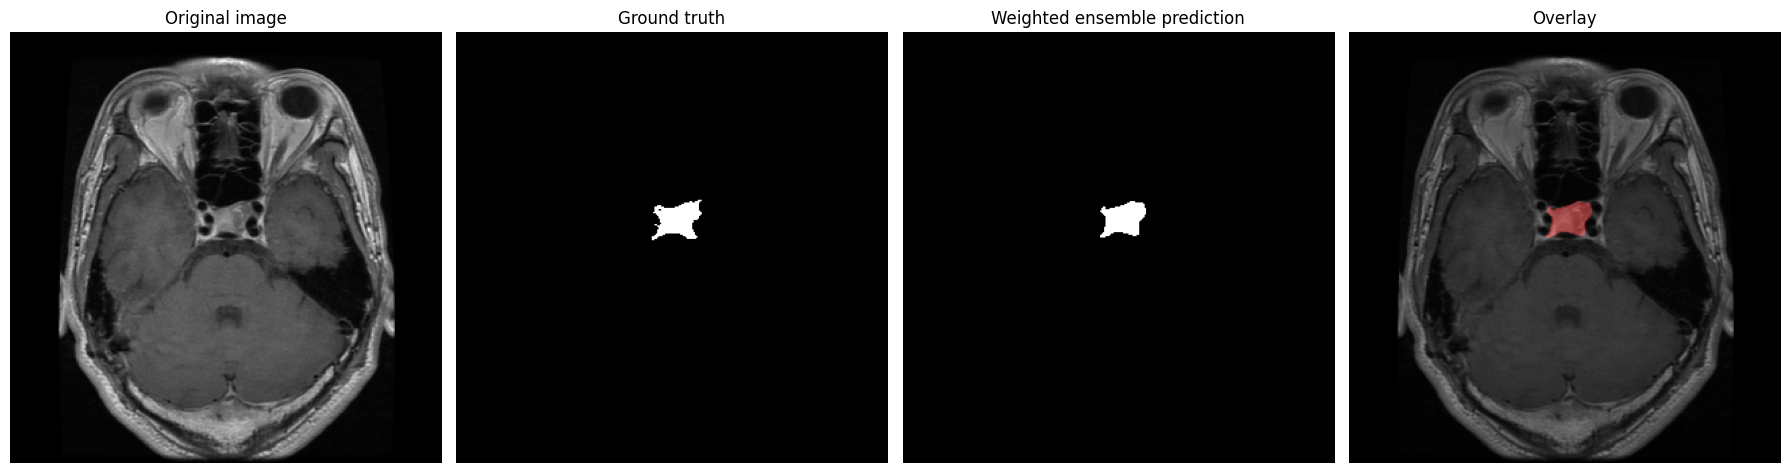

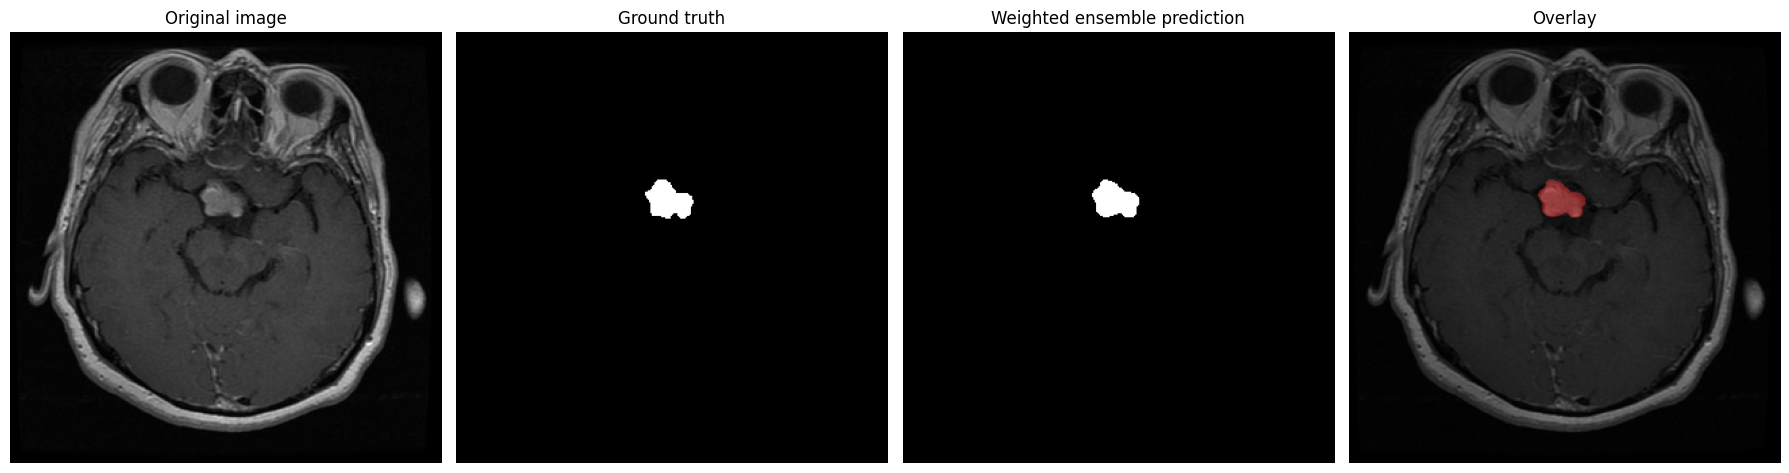

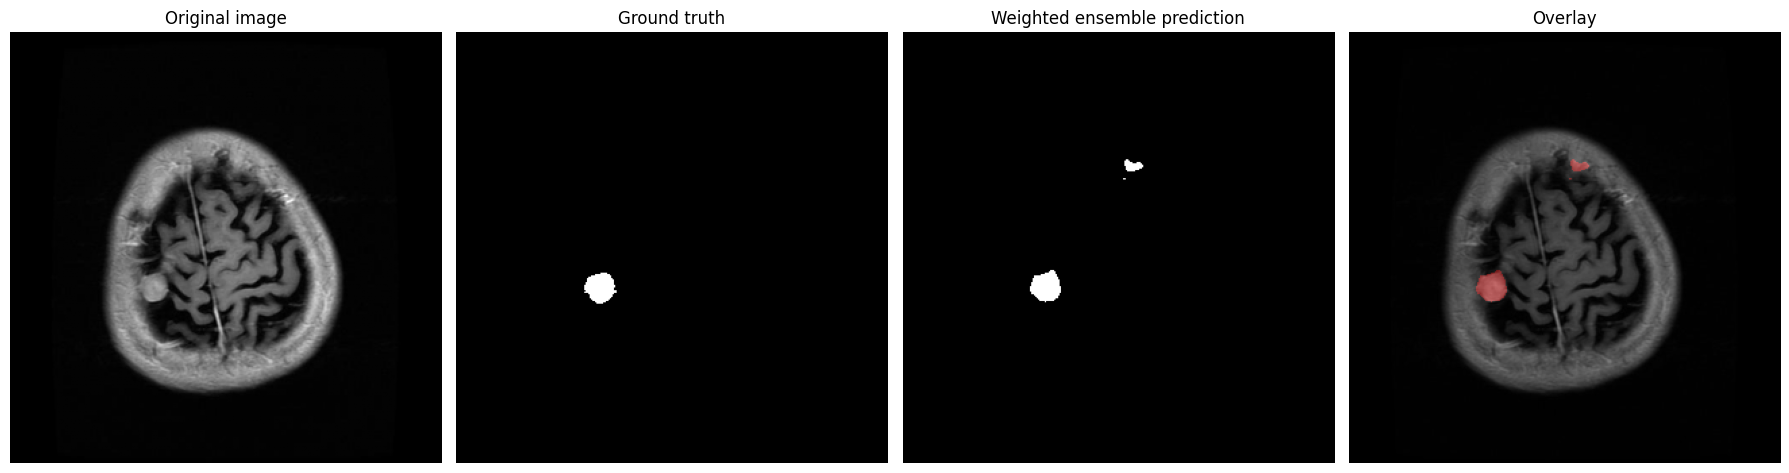

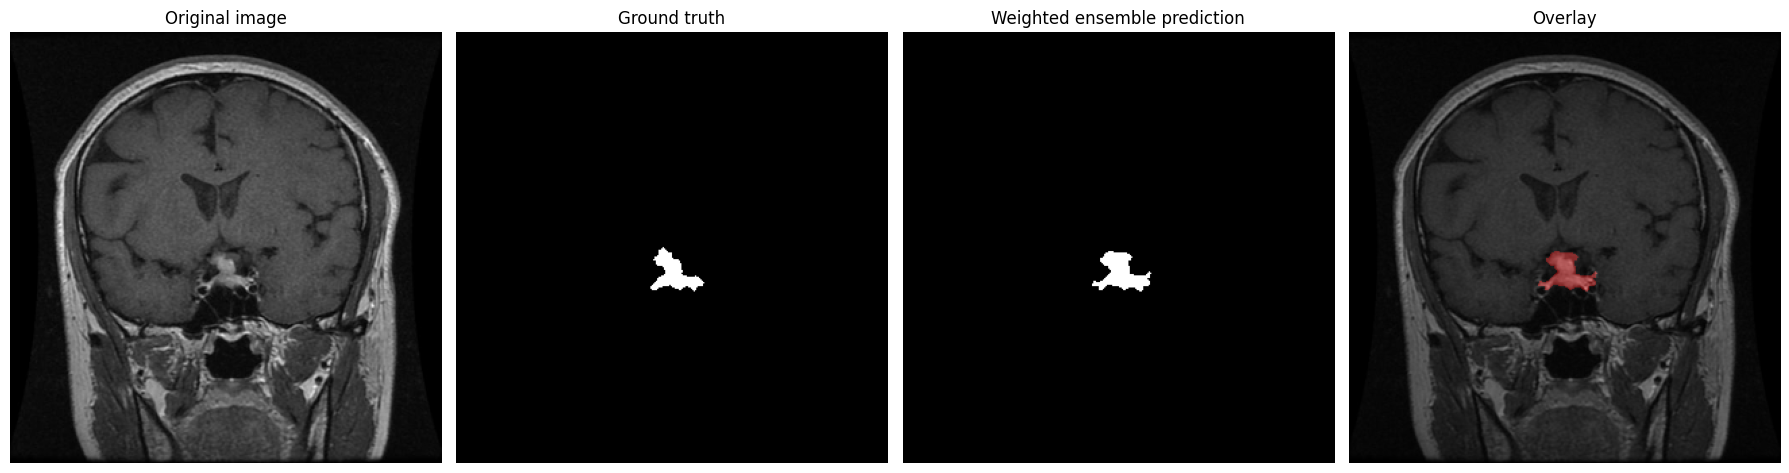

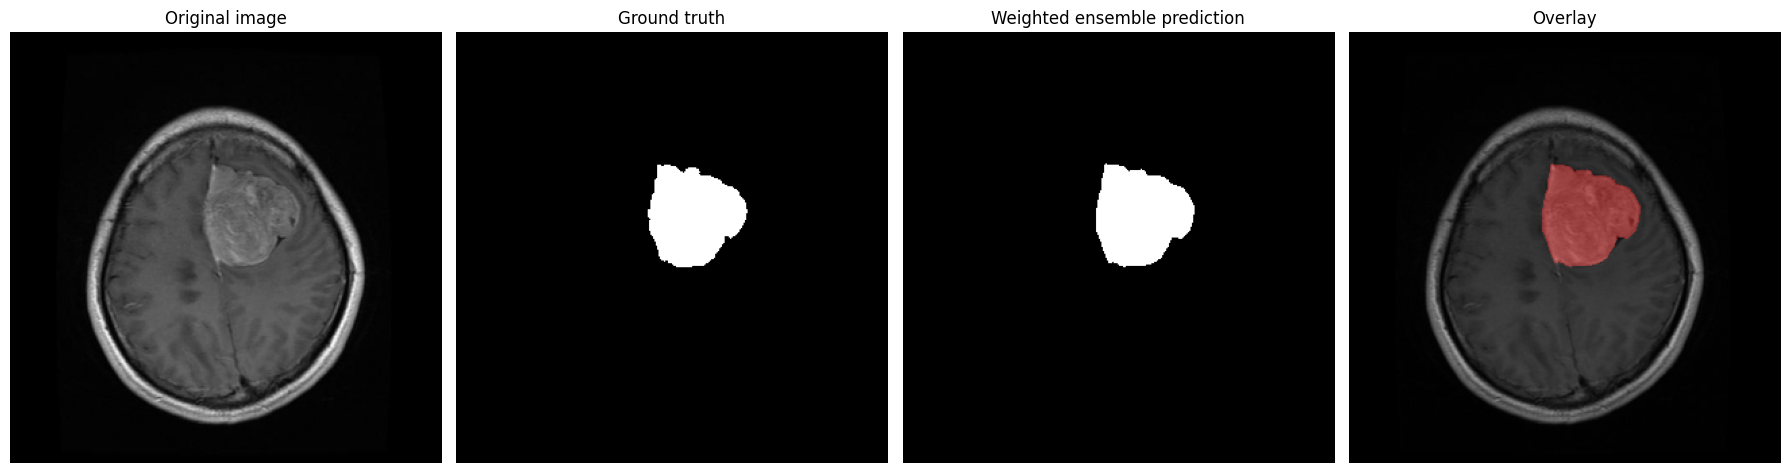

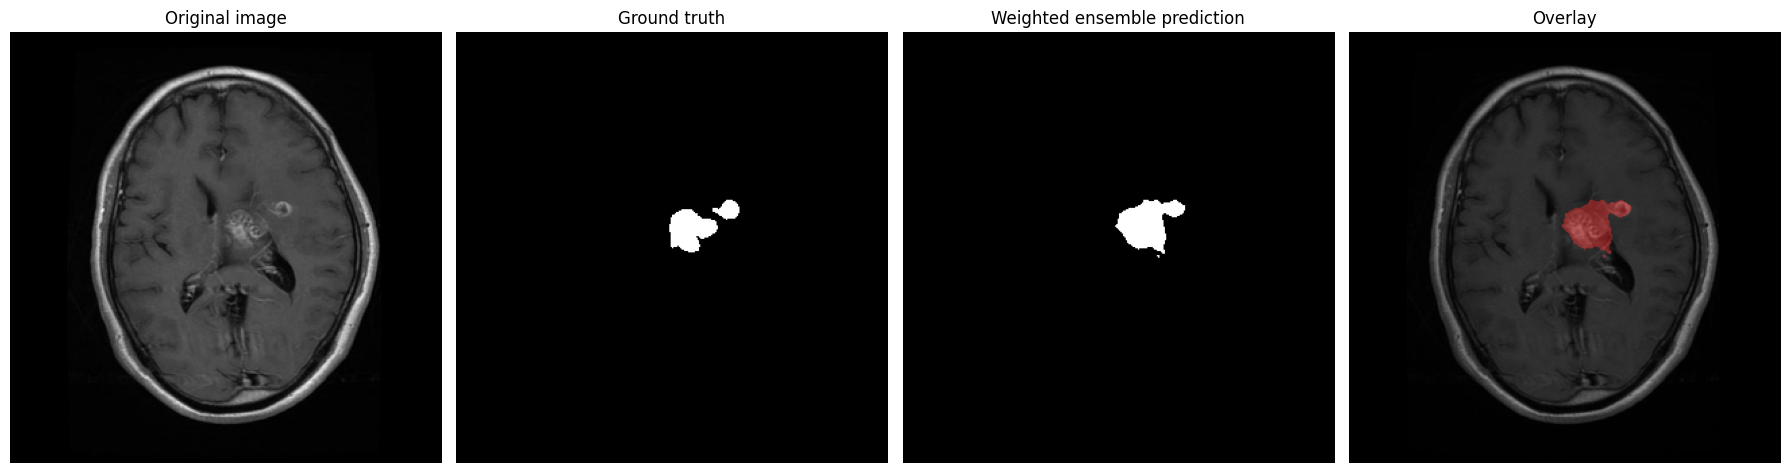

In [ ]:

# Opcionális kvalitatív ábrák a végső weighted ensemble-ről teszten

def denormalize_for_display(image_np: np.ndarray):
    img = image_np.astype(np.float32) / 255.0
    return img

def make_red_overlay(gray_img: np.ndarray, pred_mask: np.ndarray, alpha=0.35):
    gray = denormalize_for_display(gray_img)
    rgb = np.stack([gray, gray, gray], axis=-1)
    red = np.zeros_like(rgb)
    red[..., 0] = pred_mask.astype(np.float32)
    overlay = (1 - alpha) * rgb + alpha * red
    return np.clip(overlay, 0, 1)

def predict_weighted_ensemble_on_raw(image_np: np.ndarray, weights):
    p1 = model_predict_probs('unet_fno', image_np)
    p2 = model_predict_probs('attunet_fno', image_np)
    p3 = model_predict_probs('deeplabv3plus', image_np)
    w1, w2, w3 = weights
    probs = w1 * p1 + w2 * p2 + w3 * p3
    pred = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    return pred, probs.squeeze(0).cpu().numpy()

def show_final_predictions_4cols(dataset, weights, num_samples=5, save_dir=None):
    rng = np.random.default_rng(cfg.seed)
    idxs = rng.choice(len(dataset), size=min(num_samples, len(dataset)), replace=False)

    for rank, idx in enumerate(idxs, start=1):
        item = dataset[idx]
        image_np = item['image']
        gt_eval = preprocess_mask_eval(item['mask']).numpy().astype(np.uint8)
        pred_mask, _ = predict_weighted_ensemble_on_raw(image_np, weights)
        image_eval = cv2.resize(image_np, (cfg.eval_size, cfg.eval_size), interpolation=cv2.INTER_LINEAR)
        overlay = make_red_overlay(image_eval, pred_mask)

        fig, axes = plt.subplots(1, 4, figsize=(18, 5))
        axes[0].imshow(image_eval, cmap='gray'); axes[0].set_title('Original image'); axes[0].axis('off')
        axes[1].imshow(gt_eval, cmap='gray'); axes[1].set_title('Ground truth'); axes[1].axis('off')
        axes[2].imshow(pred_mask, cmap='gray'); axes[2].set_title('Weighted ensemble prediction'); axes[2].axis('off')
        axes[3].imshow(overlay); axes[3].set_title('Overlay'); axes[3].axis('off')
        plt.tight_layout()

        if save_dir is not None:
            os.makedirs(save_dir, exist_ok=True)
            out_path = os.path.join(save_dir, f'{rank:02d}_{item["id"]}_4col.png')
            plt.savefig(out_path, dpi=200, bbox_inches='tight')
        plt.show()

qual_dir = os.path.join(cfg.output_dir, 'qualitative_4col')
show_final_predictions_4cols(test_dataset, best_weights, num_samples=6, save_dir=qual_dir)


In [ ]:
print('\n===== TEST ENSEMBLE RESULTS (with std) =====')

print(f"equal_ensemble    | Dice: {equal_df['dice'].mean():.4f} ± {equal_df['dice'].std(ddof=1):.4f} | IoU: {equal_df['iou'].mean():.4f} ± {equal_df['iou'].std(ddof=1):.4f}")

print(f"weighted_ensemble | Dice: {weighted_df['dice'].mean():.4f} ± {weighted_df['dice'].std(ddof=1):.4f} | IoU: {weighted_df['iou'].mean():.4f} ± {weighted_df['iou'].std(ddof=1):.4f}")


===== TEST ENSEMBLE RESULTS (with std) =====
equal_ensemble    | Dice: 0.8570 ± 0.1801 | IoU: 0.7811 ± 0.2036
weighted_ensemble | Dice: 0.8568 ± 0.1802 | IoU: 0.7808 ± 0.2038


In [ ]:
for name, df in single_results.items():
    print(f"{name} | Dice: {df['dice'].mean():.4f} ± {df['dice'].std(ddof=1):.4f} | IoU: {df['iou'].mean():.4f} ± {df['iou'].std(ddof=1):.4f}")

unet_fno | Dice: 0.8386 ± 0.1876 | IoU: 0.7555 ± 0.2117
attunet_fno | Dice: 0.8393 ± 0.1919 | IoU: 0.7578 ± 0.2145
deeplabv3plus | Dice: 0.8557 ± 0.1691 | IoU: 0.7753 ± 0.1911


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def denormalize_for_display(image_np: np.ndarray):
    img = image_np.astype(np.float32)
    if img.max() > 1.0:
        img = img / 255.0
    return img

def make_red_overlay(gray_img: np.ndarray, pred_mask: np.ndarray, alpha=0.35):
    gray = denormalize_for_display(gray_img)
    rgb = np.stack([gray, gray, gray], axis=-1)
    red = np.zeros_like(rgb)
    red[..., 0] = pred_mask.astype(np.float32)
    overlay = (1 - alpha) * rgb + alpha * red
    return np.clip(overlay, 0, 1)

def show_ensemble_test_predictions_4cols(dataset, weights, num_samples=6, seed=42, save_dir=None):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(dataset), size=min(num_samples, len(dataset)), replace=False)

    for rank, idx in enumerate(idxs, start=1):
        item = dataset[idx]

        image_np = item["image"]          # eredeti grayscale
        mask_np = item["mask"]            # eredeti GT mask
        case_id = item["id"]

        gt_eval = preprocess_mask_eval(mask_np).numpy().astype(np.uint8)

        pred_mask, _ = predict_weighted_ensemble_on_raw(image_np, weights)

        image_eval = cv2.resize(
            image_np, (cfg.eval_size, cfg.eval_size), interpolation=cv2.INTER_LINEAR
        )

        overlay = make_red_overlay(image_eval, pred_mask)

        fig, axes = plt.subplots(1, 4, figsize=(18, 5))

        axes[0].imshow(image_eval, cmap="gray")
        axes[0].set_title("Original image")
        axes[0].axis("off")

        axes[1].imshow(gt_eval, cmap="gray")
        axes[1].set_title("Ground truth")
        axes[1].axis("off")

        axes[2].imshow(pred_mask, cmap="gray")
        axes[2].set_title("Weighted ensemble prediction")
        axes[2].axis("off")

        axes[3].imshow(overlay)
        axes[3].set_title("Overlay")
        axes[3].axis("off")

        plt.tight_layout()

        if save_dir is not None:
            os.makedirs(save_dir, exist_ok=True)
            out_path = os.path.join(save_dir, f"{rank:02d}_{case_id}_ensemble_test_4col.png")
            plt.savefig(out_path, dpi=200, bbox_inches="tight")

        plt.show()

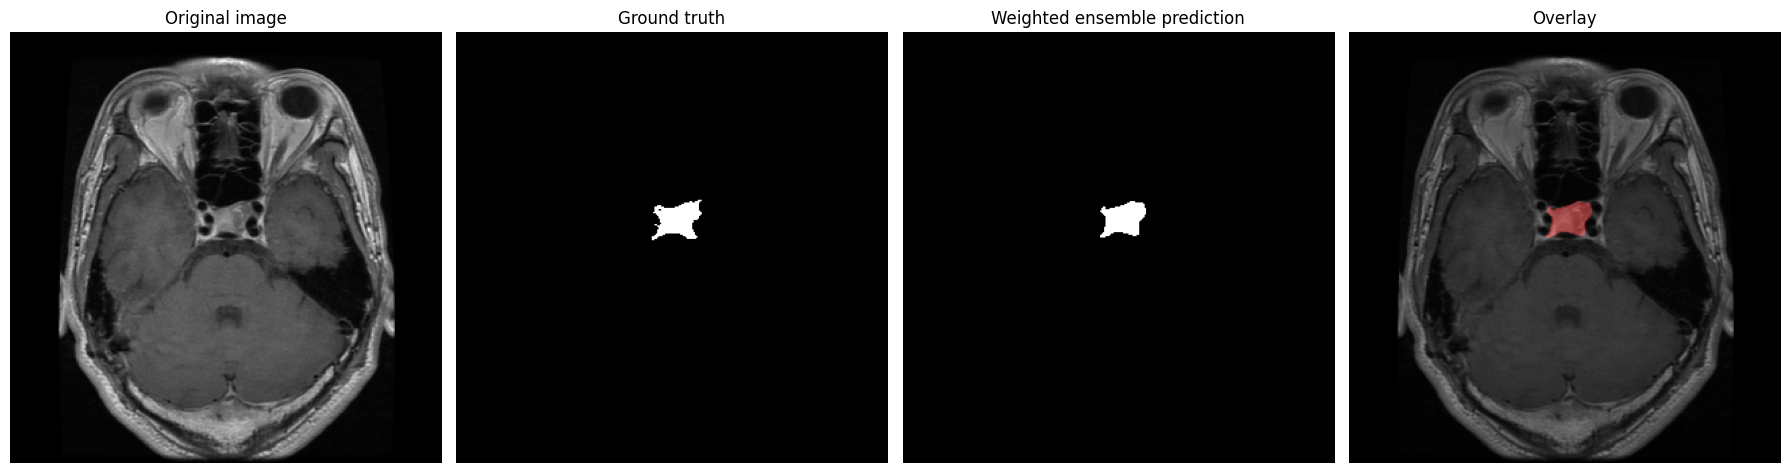

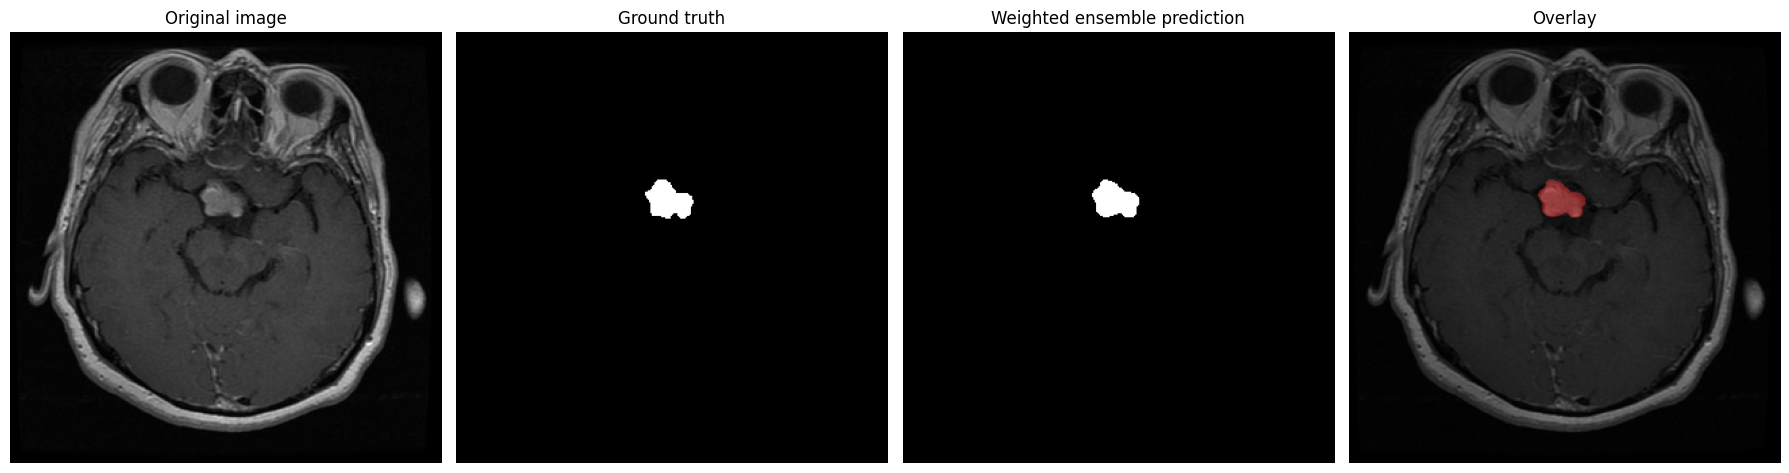

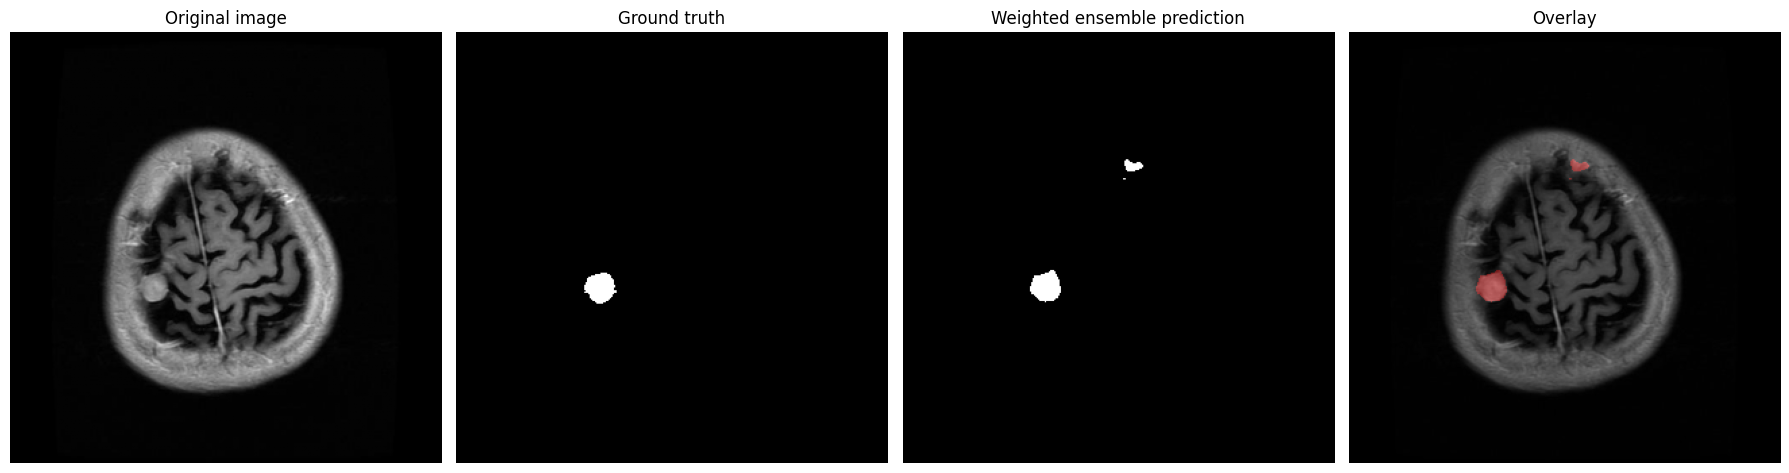

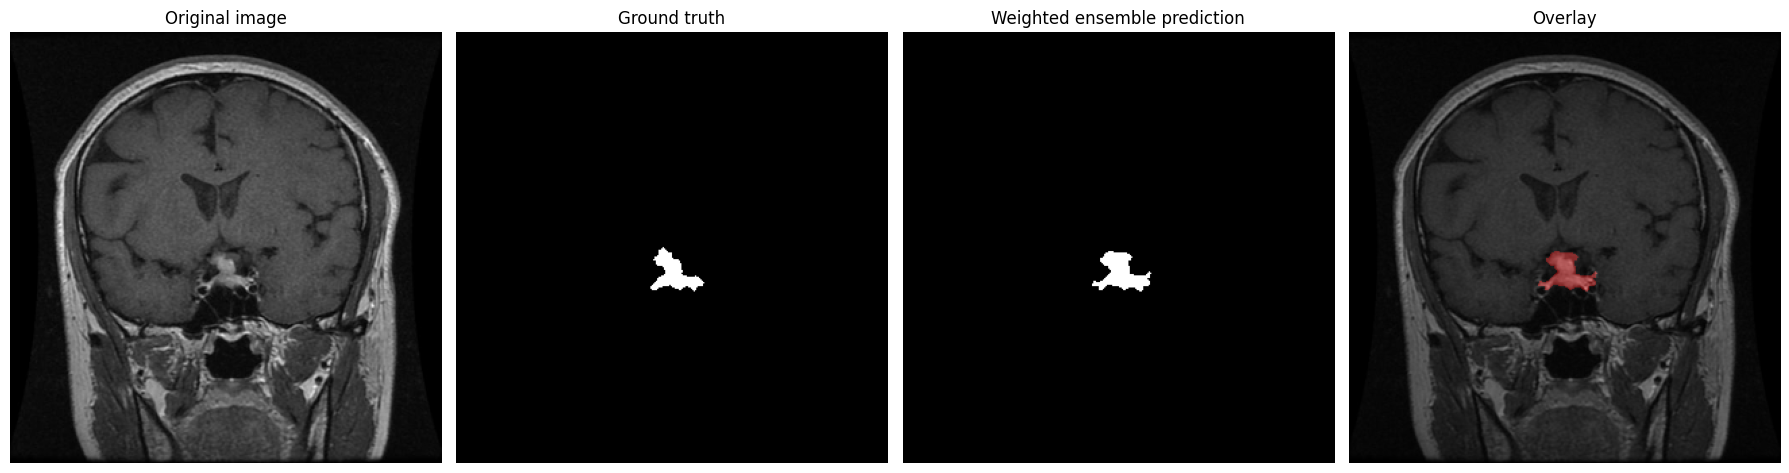

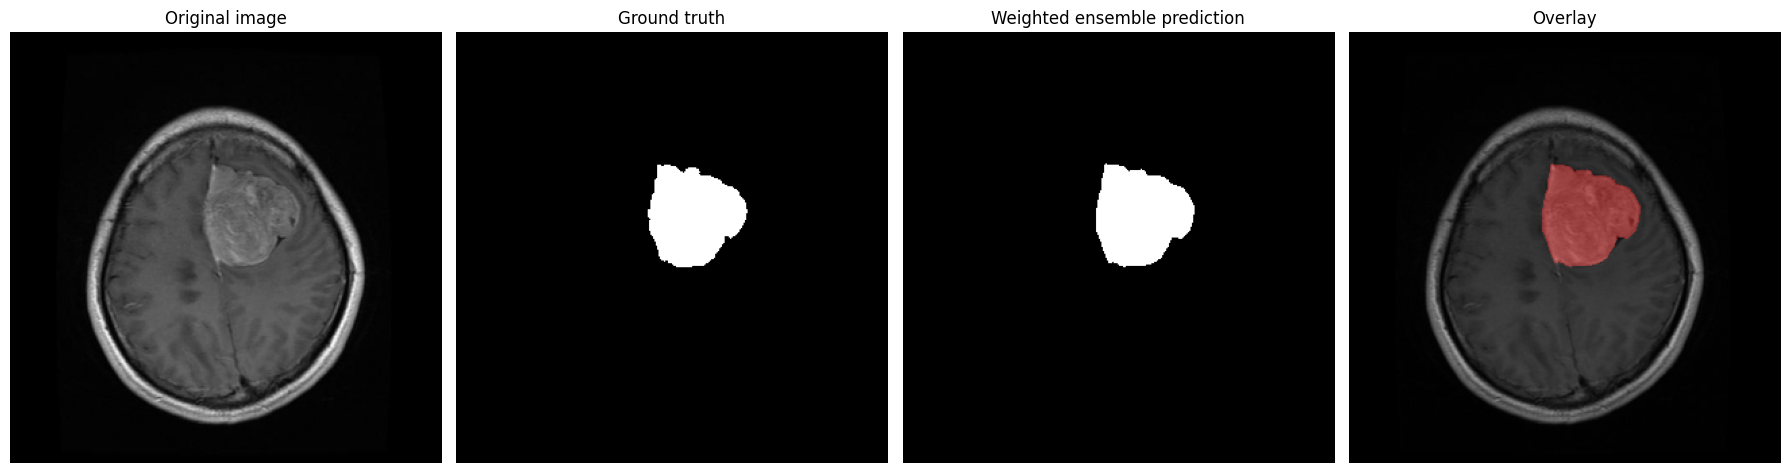

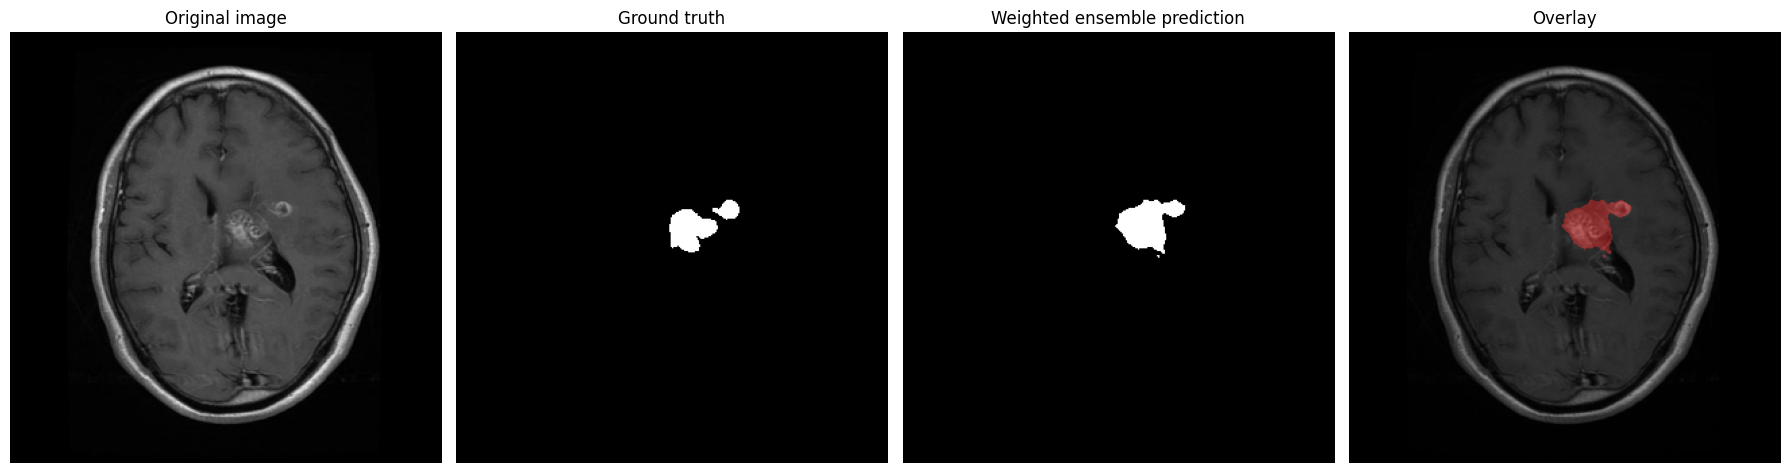

In [ ]:
qual_dir = os.path.join(cfg.output_dir, "qualitative_test_ensemble_4col")

show_ensemble_test_predictions_4cols(
    dataset=test_dataset,
    weights=best_weights,
    num_samples=6,
    seed=42,
    save_dir=qual_dir
)